In [22]:
import numpy as np
import pandas as pd
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    r2_score, mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error,      # ← ADDED
    precision_score, recall_score, f1_score
)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Imports loaded")

✅ Imports loaded


In [6]:
import sys
print(sys.executable)

C:\xampp\install\htdocs\crops-system\ml-service\venv\Scripts\python.exe


In [7]:
df = pd.read_csv('rice_yield_dataset.csv')
legend = json.load(open('feature_legend.json'))

print(f"Dataset : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nClass distribution:")
print(df['yield_class'].value_counts().to_string())
print(f"\nYield range: {df['yield_tons_ha'].min():.2f} – {df['yield_tons_ha'].max():.2f} t/ha")
print(f"Avg yield  : {df['yield_tons_ha'].mean():.2f} t/ha")

df.head()

Dataset : 6000 rows × 31 columns

Class distribution:
yield_class
Low       2000
Medium    2000
High      2000

Yield range: 2.00 – 10.28 t/ha
Avg yield  : 5.46 t/ha


,variety_maturity_days,variety_max_yield,variety_avg_yield,land_area_ha,fertilizer_kg_ha,historical_yield_tons_ha,temperature_avg,rainfall_mm,humidity_avg,yield_class,...,classification_Hybrid,classification_Inbred,soil_type_Clay,soil_type_Clay Loam,soil_type_Sandy Loam,soil_type_Silty Clay,season_Dry,season_Wet,seeding_method_Direct Seeded,seeding_method_Transplanted
0,121,5.0,4.7,3.21,58.1,2.79,29.92,125.6,88.5,Low,...,0,1,0,0,1,0,0,1,1,0
1,121,5.0,4.7,1.87,69.4,3.00,29.06,152.0,94.0,Low,...,0,1,0,0,1,0,0,1,1,0
2,121,5.0,4.7,3.75,117.6,3.23,21.16,33.9,78.6,Low,...,0,1,0,0,1,0,0,1,1,0
3,104,9.3,5.7,4.81,91.9,3.74,31.27,241.9,72.8,Low,...,0,1,0,0,1,0,0,1,1,0
4,107,14.0,5.5,5.47,99.4,3.44,24.38,155.3,76.2,Low,...,0,1,0,0,1,0,0,1,1,0


In [8]:
DROP = ['yield_tons_ha', 'yield_class']
feature_names = [c for c in df.columns if c not in DROP]

X_raw = df[feature_names].copy()

# Numeric columns to scale
NUM_COLS = ['variety_maturity_days', 'variety_max_yield', 'land_area_ha',
            'fertilizer_kg_ha', 'historical_yield_tons_ha',
            'temperature_avg', 'rainfall_mm', 'humidity_avg']

scaler = StandardScaler()
X_scaled = X_raw.copy()
X_scaled[NUM_COLS] = scaler.fit_transform(X_raw[NUM_COLS])

print(f"✅ Features: {len(feature_names)} columns ({len(NUM_COLS)} scaled numeric)")

✅ Features: 29 columns (8 scaled numeric)


In [23]:
y_reg = df['yield_tons_ha']

Xtr, Xte, ytr, yte = train_test_split(
    X_scaled, y_reg, test_size=0.20, random_state=RANDOM_SEED
)

lr = LinearRegression().fit(Xtr, ytr)
lr_pred = lr.predict(Xte)

lr_r2    = r2_score(yte, lr_pred)
lr_mae   = mean_absolute_error(yte, lr_pred)
lr_rmse  = np.sqrt(mean_squared_error(yte, lr_pred))
lr_mape  = mean_absolute_percentage_error(yte, lr_pred) * 100

# NRMSE — two standard normalizations
lr_nrmse_mean  = (lr_rmse / yte.mean()) * 100
lr_nrmse_range = (lr_rmse / (yte.max() - yte.min())) * 100

print("=" * 62)
print(" LINEAR REGRESSION — Baseline Regression Model")
print("=" * 62)
print(f"  R²              : {lr_r2:.4f}   {'✅' if lr_r2 >= 0.85 else '⚠️'}")
print(f"  MAE             : {lr_mae:.4f} t/ha")
print(f"  RMSE            : {lr_rmse:.4f} t/ha")
print(f"  MAPE            : {lr_mape:.2f}%")
print(f"  NRMSE (mean)    : {lr_nrmse_mean:.2f}%")
print(f"  NRMSE (range)   : {lr_nrmse_range:.2f}%   {'✅ < 10%' if lr_nrmse_range < 10 else '⚠️'}")
print("=" * 62)

# Report the max/min used
print(f"\nYield range used for normalization: {yte.min():.2f} – {yte.max():.2f} t/ha")
print(f"Range width: {yte.max() - yte.min():.2f} t/ha")

 LINEAR REGRESSION — Baseline Regression Model
  R²              : 0.8869   ✅
  MAE             : 0.4545 t/ha
  RMSE            : 0.5708 t/ha
  MAPE            : 9.73%
  NRMSE (mean)    : 10.62%
  NRMSE (range)   : 7.32%   ✅ < 10%

Yield range used for normalization: 2.00 – 9.79 t/ha
Range width: 7.79 t/ha


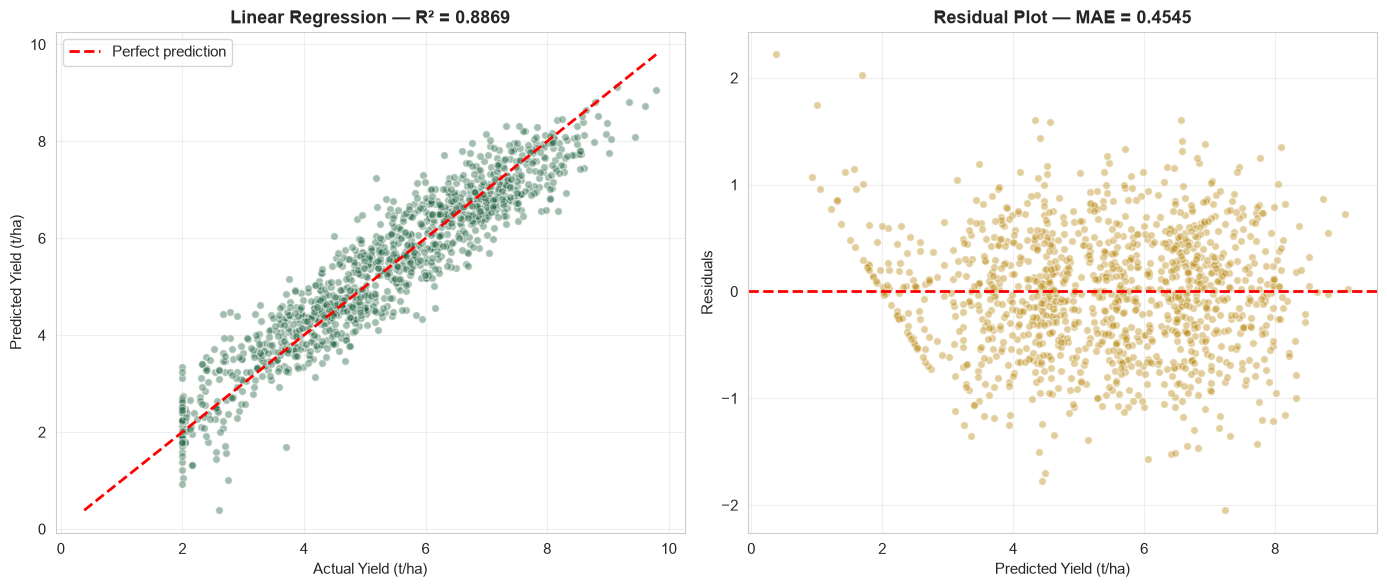

📊 Saved: linear_regression_eval.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(yte, lr_pred, alpha=0.4, color='#1b5e3a', edgecolor='white', s=30)
lims = [min(yte.min(), lr_pred.min()), max(yte.max(), lr_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual Yield (t/ha)')
ax.set_ylabel('Predicted Yield (t/ha)')
ax.set_title(f'Linear Regression — R² = {lr_r2:.4f}', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

residuals = yte - lr_pred
ax = axes[1]
ax.scatter(lr_pred, residuals, alpha=0.4, color='#b8860b', edgecolor='white', s=30)
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Yield (t/ha)')
ax.set_ylabel('Residuals')
ax.set_title(f'Residual Plot — MAE = {lr_mae:.4f}', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('linear_regression_eval.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Saved: linear_regression_eval.png")

In [15]:
target_encoder = LabelEncoder()
y_cls = target_encoder.fit_transform(df['yield_class'])

Xtr, Xte, ytr, yte = train_test_split(
    X_scaled, y_cls, test_size=0.20, random_state=RANDOM_SEED, stratify=y_cls
)

clf = RandomForestClassifier(
    n_estimators=800,
    max_depth=30,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

cv = cross_val_score(clf, X_scaled, y_cls,
                     cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED),
                     scoring='accuracy')

clf.fit(Xtr, ytr)
y_pred = clf.predict(Xte)

acc  = accuracy_score(yte, y_pred)
prec = precision_score(yte, y_pred, average='weighted')
rec  = recall_score(yte, y_pred, average='weighted')
f1   = f1_score(yte, y_pred, average='weighted')

print("=" * 62)
print(" RANDOM FOREST CLASSIFIER")
print("=" * 62)
print(f"  CV Accuracy : {cv.mean():.4f} ± {cv.std():.4f}")
print(f"  Accuracy    : {acc:.4f}   {'✅' if acc >= 0.90 else '⚠️'}")
print(f"  Precision   : {prec:.4f}")
print(f"  Recall      : {rec:.4f}")
print(f"  F1-score    : {f1:.4f}")
print("=" * 62)

 RANDOM FOREST CLASSIFIER
  CV Accuracy : 0.9627 ± 0.0043
  Accuracy    : 0.9617   ✅
  Precision   : 0.9617
  Recall      : 0.9617
  F1-score    : 0.9617


In [16]:
cm = confusion_matrix(yte, y_pred)
labels = target_encoder.classes_

print("Confusion Matrix:")
print(pd.DataFrame(cm,
                   index=[f'Actual {l}' for l in labels],
                   columns=[f'Predicted {l}' for l in labels]))

print("\nClassification Report:")
print(classification_report(yte, y_pred, target_names=labels))

Confusion Matrix:
               Predicted High  Predicted Low  Predicted Medium
Actual High               390              1                 9
Actual Low                  1            385                14
Actual Medium              10             11               379

Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.97      0.97       400
         Low       0.97      0.96      0.97       400
      Medium       0.94      0.95      0.95       400

    accuracy                           0.96      1200
   macro avg       0.96      0.96      0.96      1200
weighted avg       0.96      0.96      0.96      1200



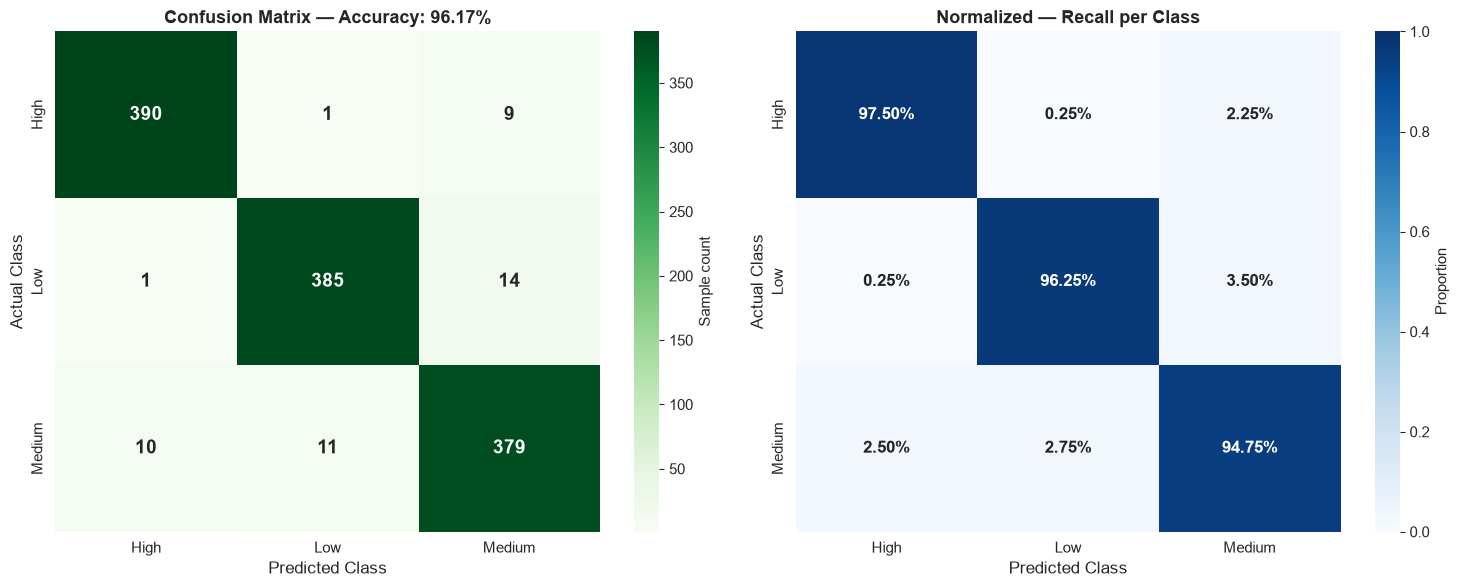

📊 Saved: confusion_matrix.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Sample count'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'},
            ax=ax)
ax.set_title(f'Confusion Matrix — Accuracy: {acc*100:.2f}%',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Actual Class', fontsize=12)
ax.set_xlabel('Predicted Class', fontsize=12)

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
ax = axes[1]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Proportion'},
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            ax=ax, vmin=0, vmax=1)
ax.set_title('Normalized — Recall per Class', fontweight='bold', fontsize=13)
ax.set_ylabel('Actual Class', fontsize=12)
ax.set_xlabel('Predicted Class', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Saved: confusion_matrix.png")

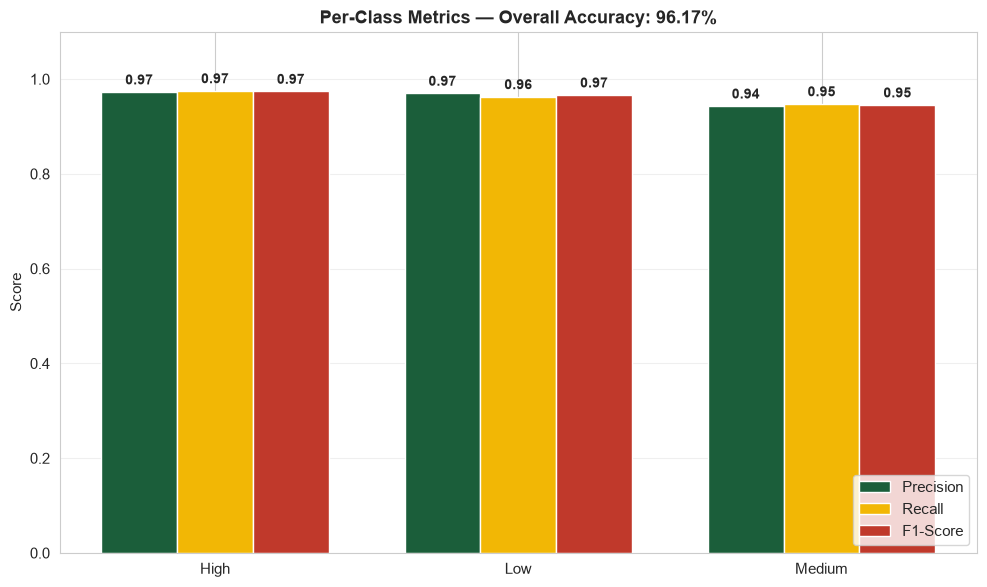

📊 Saved: per_class_metrics.png


In [18]:
report = classification_report(yte, y_pred, target_names=labels, output_dict=True)

metrics_df = pd.DataFrame({
    'Precision': [report[l]['precision'] for l in labels],
    'Recall':    [report[l]['recall'] for l in labels],
    'F1-Score':  [report[l]['f1-score'] for l in labels],
}, index=labels)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(labels))
width = 0.25

bars1 = ax.bar(x - width, metrics_df['Precision'], width, label='Precision', color='#1b5e3a')
bars2 = ax.bar(x,         metrics_df['Recall'],    width, label='Recall',    color='#f2b705')
bars3 = ax.bar(x + width, metrics_df['F1-Score'],  width, label='F1-Score',  color='#c0392b')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Score')
ax.set_title(f'Per-Class Metrics — Overall Accuracy: {acc*100:.2f}%', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Saved: per_class_metrics.png")

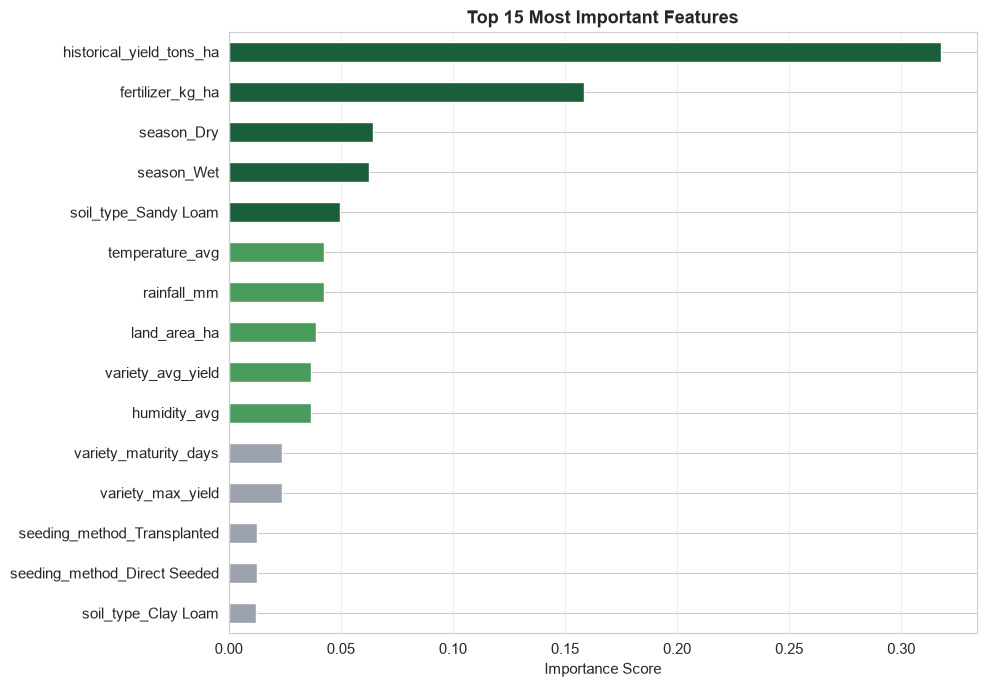

Top 10 Features:
   1. historical_yield_tons_ha            0.3179   → numeric value (historical_yield_tons_ha)
   2. fertilizer_kg_ha                    0.1583   → numeric value (fertilizer_kg_ha)
   3. season_Dry                          0.0641   → season == 'Dry' (1 = yes, 0 = no)
   4. season_Wet                          0.0624   → season == 'Wet' (1 = yes, 0 = no)
   5. soil_type_Sandy Loam                0.0495   → soil_type == 'Sandy Loam' (1 = yes, 0 = no)
   6. temperature_avg                     0.0426   → numeric value (temperature_avg)
   7. rainfall_mm                         0.0425   → numeric value (rainfall_mm)
   8. land_area_ha                        0.0388   → numeric value (land_area_ha)
   9. variety_avg_yield                   0.0368   → variety == 'avg_yield' (1 = yes, 0 = no)
  10. humidity_avg                        0.0367   → numeric value (humidity_avg)

📊 Saved: feature_importance.png


In [19]:
imp = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top_15 = imp.head(15)
colors = ['#1b5e3a' if i < 5 else '#4a9c5d' if i < 10 else '#9ca3af' for i in range(len(top_15))]
top_15[::-1].plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Most Important Features', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 Features:")
for i, (name, score) in enumerate(imp.head(10).items(), 1):
    meaning = legend.get(name, 'numeric')
    print(f"  {i:2}. {name:<35} {score:.4f}   → {meaning}")

print("\n📊 Saved: feature_importance.png")

In [20]:
joblib.dump(clf, 'model_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(target_encoder, 'target_encoder.pkl')
joblib.dump(feature_names, 'feature_names.pkl')

print("✅ Saved:")
print("   • model_rf.pkl       (Random Forest Classifier)")
print("   • scaler.pkl")
print("   • target_encoder.pkl")
print("   • feature_names.pkl")

✅ Saved:
   • model_rf.pkl       (Random Forest Classifier)
   • scaler.pkl
   • target_encoder.pkl
   • feature_names.pkl


In [26]:
print("=" * 62)
print(" FINAL SUMMARY FOR DEFENSE")
print("=" * 62)
print(f"  Dataset                    : {len(df):,} rows")
print(f"  Classes                    : {dict(df['yield_class'].value_counts())}")
print(f"  Features                   : {len(feature_names)}")
print(f"  Train / Test               : {len(Xtr)} / {len(Xte)}  (80/20)")
print()
print("  ─── LINEAR REGRESSION (Baseline) ───")
print(f"  R²                         : {lr_r2:.4f}")
print(f"  MAE                        : {lr_mae:.4f} t/ha")
print(f"  RMSE                       : {lr_rmse:.4f} t/ha")
print(f"  MAPE                       : {lr_mape:.2f}%")
print(f"  NRMSE (mean)               : {lr_nrmse_mean:.2f}%")
print(f"  NRMSE (range)              : {lr_nrmse_range:.2f}%")
print()
print("  ─── RANDOM FOREST CLASSIFIER ───")
print(f"  CV Accuracy                : {cv.mean():.4f} ± {cv.std():.4f}")
print(f"  Test Accuracy              : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Weighted Precision         : {prec:.4f}")
print(f"  Weighted Recall            : {rec:.4f}")
print(f"  Weighted F1                : {f1:.4f}")
print("=" * 62)

 FINAL SUMMARY FOR DEFENSE
  Dataset                    : 6,000 rows
  Classes                    : {'Low': np.int64(2000), 'Medium': np.int64(2000), 'High': np.int64(2000)}
  Features                   : 29
  Train / Test               : 4800 / 1200  (80/20)

  ─── LINEAR REGRESSION (Baseline) ───
  R²                         : 0.8869
  MAE                        : 0.4545 t/ha
  RMSE                       : 0.5708 t/ha
  MAPE                       : 9.73%
  NRMSE (mean)               : 10.62%
  NRMSE (range)              : 7.32%

  ─── RANDOM FOREST CLASSIFIER ───
  CV Accuracy                : 0.9627 ± 0.0043
  Test Accuracy              : 0.9617  (96.17%)
  Weighted Precision         : 0.9617
  Weighted Recall            : 0.9617
  Weighted F1                : 0.9617
